# Model meets reality: SGP three-case summary

Three case days at the ARM SGP site: 019-05-17, 018-07-09), 2019-09-29.  
Two models: **SCREAM** (5 km doubly-periodic) and **WRF-LASSO** (250 m reference LES).  
Observations: ARM ARSCL cloud mask, MWR liquid-water path, downwelling shortwave radiation, and rawinsonde soundings.

In [1]:
import os, warnings
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import netCDF4 as nc
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore', category=RuntimeWarning)
os.environ['PROJ_LIB']  = '/opt/conda/share/proj'
os.environ['PROJ_DATA'] = '/opt/conda/share/proj'

SCREAM_ROOT = Path('/data/project/ARM_Summer_School_2026/data/modeling/dpscream')
LASSO_ROOT  = Path('/data/project/ARM_Summer_School_2026/data/modeling/lasso')
SW_PATH     = Path('/data/archive/sgp/sgpqcrad1longE13.c2')

C_SCREAM = '#1f77b4'
C_WRF    = '#ff7f0e'
C_OBS    = '#222222'
C_LCL    = '#2ca02c'
C_CB     = '#9467bd'

CASE_COLOR = {'0517': '#0072B2', '0709': '#D55E00', '0929': '#009E73'}
CASE_ORDER = ['0709', '0517', '0929']
UTC_TO_LST = pd.Timedelta(hours=-5)

# snd_id differs from sim for 0929: only id5 sounding exists on disk
CASES = {
    '0709': {'date': '2018-07-09', 'yyyymmdd': '20180709', 'sim': 8, 'snd_id': 8, 'regime': 'deeper cumulus'},
    '0517': {'date': '2019-05-17', 'yyyymmdd': '20190517', 'sim': 4, 'snd_id': 4, 'regime': 'shallow cumulus'},
    '0929': {'date': '2019-09-29', 'yyyymmdd': '20190929', 'sim': 4, 'snd_id': 5, 'regime': 'fall transition'},
}
for k, v in CASES.items():
    d, s, y = v['yyyymmdd'], v['sim'], v['date']
    base = LASSO_ROOT / d / f'sgplassodiagconfobsmod{s}C1.m1' / 'obs_model'
    v['f_scream']   = SCREAM_ROOT / f'scream_dpxx_LASSO_SGP_{y}.fullfield.AVERAGE.nhours_x1.{y}-43200.nc'
    v['f_obsmodz']  = base / f'sgplassodiagobsmodz{s}C1.m1.{d}.120000.nc'
    v['f_obsmod']   = base / f'sgplassodiagobsmod{s}C1.m1.{d}.120000.nc'
    v['f_mod']      = base / f'sgplassomod{s}C1.m1.{d}.120000.nc'
    v['f_sounding'] = LASSO_ROOT / d / f'{d}_sgplassoconf_id{v["snd_id"]}' / 'input_sounding'
    v['wrfout_glob']= str(LASSO_ROOT / d / f'sgplassodiagraw{s}C1.m1' / 'raw_model' / 'wrfout_d01_*.nc')

plt.rcParams.update({
    'figure.dpi':       130,
    'savefig.dpi':      200,
    'savefig.bbox':     'tight',
    'font.size':        15,
    'axes.titlesize':   14,
    'axes.labelsize':   15,
    'xtick.labelsize':  14,
    'ytick.labelsize':  14,
    'legend.fontsize':  13,
    'figure.titlesize': 17,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.linewidth':   1.2,
    'lines.linewidth':  2.2,
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linewidth':   0.7,
})
print('Setup done.')

Setup done.


In [2]:
def open_wrf_vap(path):
    """Open LASSO WRF VAP; reattach `height` dropped by xarray (it is both dim and var)."""
    ds  = xr.open_dataset(path, decode_coords=False, drop_variables=['height'])
    raw = nc.Dataset(path)
    if 'height' in raw.variables:
        ds = ds.assign({'height_km': (raw.variables['height'].dimensions,
                                      raw.variables['height'][:])})
    raw.close()
    return ds


def to_lst(times):
    return pd.DatetimeIndex(times) + UTC_TO_LST


def hod(times_lst):
    return times_lst.hour + times_lst.minute / 60.0


def scream_z_km(ds):
    """Time-mean domain-mean SCREAM z_mid → km AGL (top-first ordering preserved)."""
    z = ds['z_mid'].mean(['time', 'ncol']).values
    return (z - z.min()) / 1000.0


def scream_z_km_t(ds):
    """Time-resolved domain-mean z_mid → km AGL DataArray (time, lev)."""
    z = ds['z_mid'].mean('ncol')          # (time, lev), metres AMSL
    return (z - z.min('lev')) / 1000.0    # km AGL


def scream_low_cf(ds, z_top_m=5000.0):
    """Max cldfrac_tot_for_analysis below z_top_m metres, averaged over ncol."""
    return (ds['cldfrac_tot_for_analysis']
            .where(ds['z_mid'] < z_top_m)
            .max('lev')
            .mean('ncol')
            .values)


def open_case(short):
    c = CASES[short]
    return dict(
        case=short, date=c['date'], regime=c['regime'],
        scream  = xr.open_dataset(c['f_scream']),
        obsmodz = open_wrf_vap(c['f_obsmodz']),
        obsmod  = open_wrf_vap(c['f_obsmod']),
        mod     = open_wrf_vap(c['f_mod']),
    )


def load_sounding(short):
    snd   = np.loadtxt(CASES[short]['f_sounding'], skiprows=1)
    z_km  = snd[:, 0] / 1000.0   # column 0: height in metres
    theta = snd[:, 1]             # column 1: theta in K
    return theta, z_km


def load_sw_obs(yyyymmdd, resample='10min'):
    d = int(yyyymmdd)
    files = [str(SW_PATH / f'sgpqcrad1longE13.c2.{d}.000000.cdf'),
             str(SW_PATH / f'sgpqcrad1longE13.c2.{d+1}.000000.cdf')]
    sw = xr.open_mfdataset(files).BestEstimate_down_short_hemisp
    sw = sw.isel(time=slice(12 * 60, (24 + 4) * 60)).resample(time=resample).mean()
    return sw.assign_coords(time=sw.time + UTC_TO_LST)


def load_wrf_swdnb(short):
    pat   = CASES[short]['wrfout_glob']
    ds    = xr.open_mfdataset(sorted(glob(pat)), combine='nested', concat_dim='Time')
    times = pd.to_datetime(
        [bytes(t).decode().replace('_', 'T') for t in ds['Times'].values]
    ) + UTC_TO_LST
    return ds['SWDNB'].assign_coords(Time=times).mean(['south_north', 'west_east'])


def fmt_haxis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))
    ax.set_xlabel('Local Solar Time [h]')


def nearest_t(times, target_ts):
    return int(np.argmin(np.abs(times - target_ts)))


print('Helpers ready.')


Helpers ready.


In [3]:
BUNDLES = {}
for short in CASE_ORDER:
    b = open_case(short)
    b['t_sc']     = to_lst(b['scream']['time'].values)
    b['t_oz']     = to_lst(b['obsmodz']['time'].values)
    b['t_mod']    = to_lst(b['mod']['time'].values)
    b['t_omd']    = to_lst(b['obsmod']['time'].values)
    b['h_sc']     = hod(b['t_sc'])
    b['h_oz']     = hod(b['t_oz'])
    b['z_sc_km']  = scream_z_km(b['scream'])
    b['z_sc_km_t']= scream_z_km_t(b['scream'])      # (time, lev) DataArray
    b['z_wrf_km'] = b['obsmodz']['height_km'].mean('time').values
    BUNDLES[short] = b
    print(f'  {short}  {b["date"]}  ok')

sw_obs    = {s: load_sw_obs(CASES[s]['yyyymmdd']) for s in CASE_ORDER}
wrf_swdnb = {s: load_wrf_swdnb(s)                 for s in CASE_ORDER}
print('SW radiation loaded.')


  0709  2018-07-09  ok
  0517  2019-05-17  ok
  0929  2019-09-29  ok
SW radiation loaded.


## Fig 1 — Cloud-fraction curtains

Time–height fields for the full diurnal cycle (6–23 LST). Columns: SCREAM `cldfrac_tot`, WRF-LASSO `cloud_fraction`, ARSCL `cloud_fraction_mask_arscl`. Shared 0–1 colour scale; white = high fraction, dark blue = none.

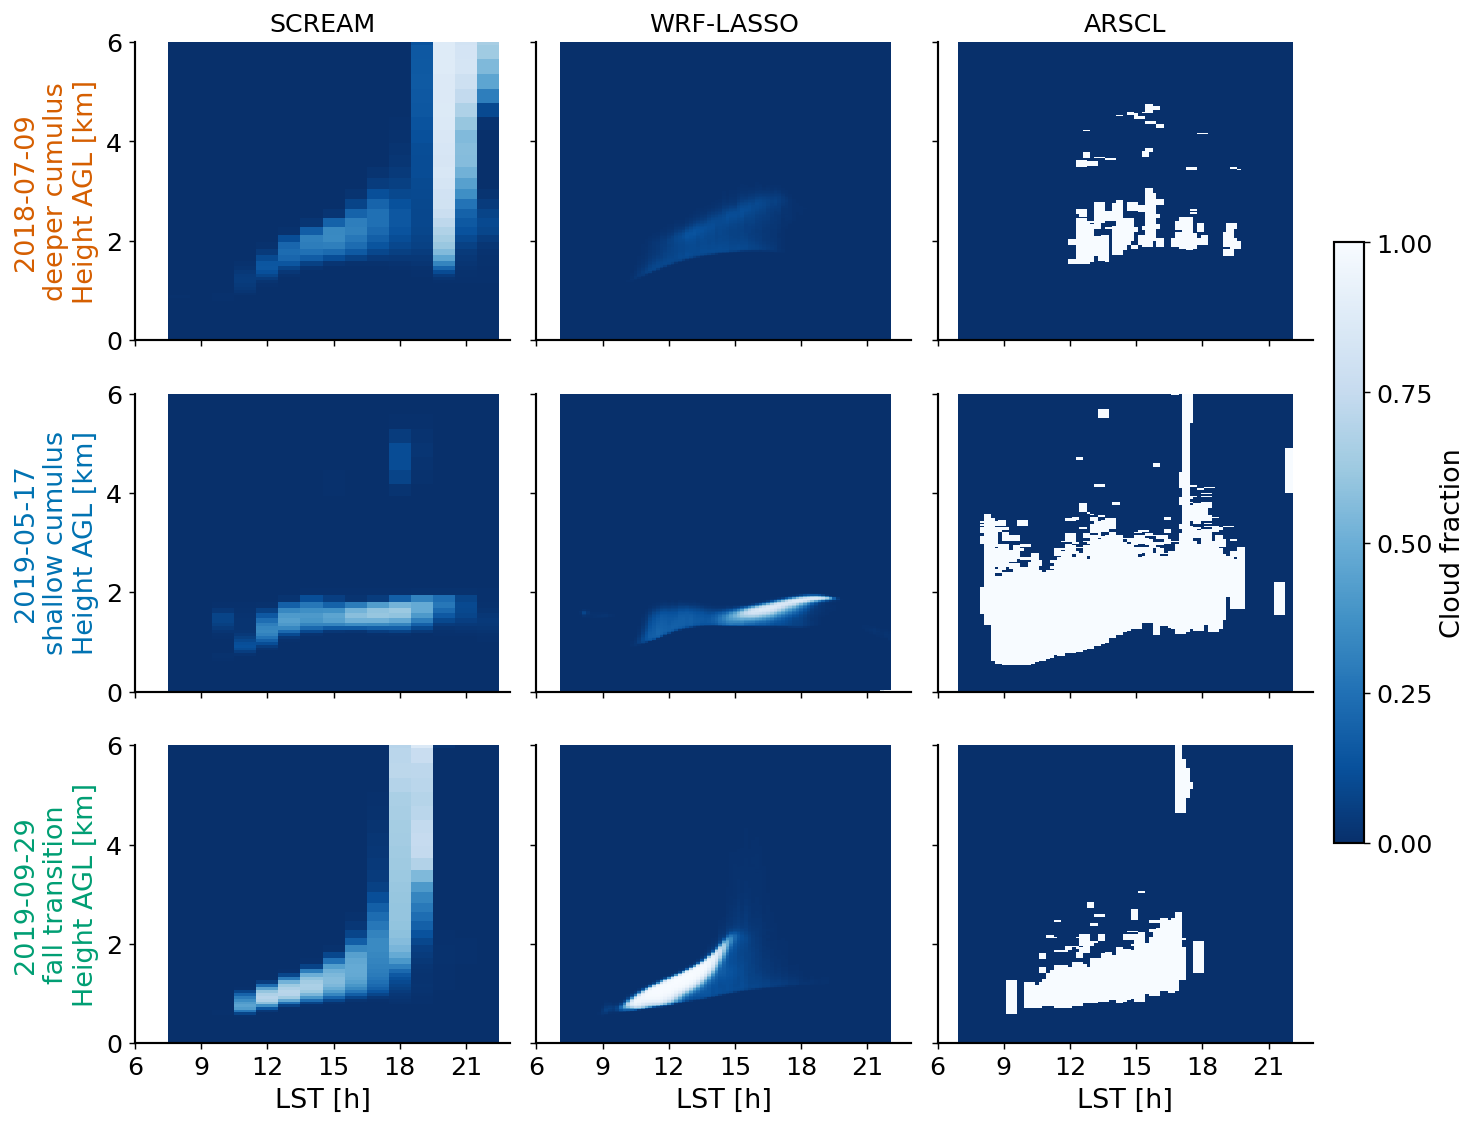

In [4]:
Z_TOP = 6.0

fig, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True, sharey=True,
                         gridspec_kw=dict(hspace=0.18, wspace=0.07))

for r, short in enumerate(CASE_ORDER):
    b = BUNDLES[short]
    panels = [
        (b['h_sc'], b['z_sc_km'],
         b['scream']['cldfrac_tot'].mean('ncol').values.T, 'SCREAM'),
        (b['h_oz'], b['z_wrf_km'],
         b['obsmodz']['cloud_fraction'].values.T,          'WRF-LASSO'),
        (b['h_oz'], b['z_wrf_km'],
         b['obsmodz']['cloud_fraction_mask_arscl'].values.T,'ARSCL'),
    ]
    for c, (hh, zz, arr, ttl) in enumerate(panels):
        ax = axes[r, c]
        pc = ax.pcolormesh(hh, zz, arr, cmap='Blues_r', vmin=0, vmax=1, shading='auto')
        ax.set_ylim(0, Z_TOP)
        ax.set_xlim(6, 23)
        ax.set_xticks(np.arange(6, 24, 3))
        ax.grid(False)
        if r == 0:
            ax.set_title(ttl)
        if c == 0:
            ax.set_ylabel(f"{b['date']}\n{b['regime']}\nHeight AGL [km]",
                          color=CASE_COLOR[short])
        if r == 2:
            ax.set_xlabel('LST [h]')

fig.colorbar(pc, ax=axes, shrink=0.6, pad=0.015,
             label='Cloud fraction', ticks=[0, 0.25, 0.5, 0.75, 1.0])
plt.show()

## Fig 2 & 3 — Liquid water path and low cloud fraction

Both metrics use one panel per case with three sources in fixed order (SCREAM → WRF-LASSO → ARM obs). SCREAM low cloud fraction is `cldfrac_tot_for_analysis.where(z_mid < 5000 m).max(lev).mean(ncol)`; WRF-LASSO and ARSCL values come from the pre-computed `low_cloud_fraction_arscl` field in the obsmod VAP.


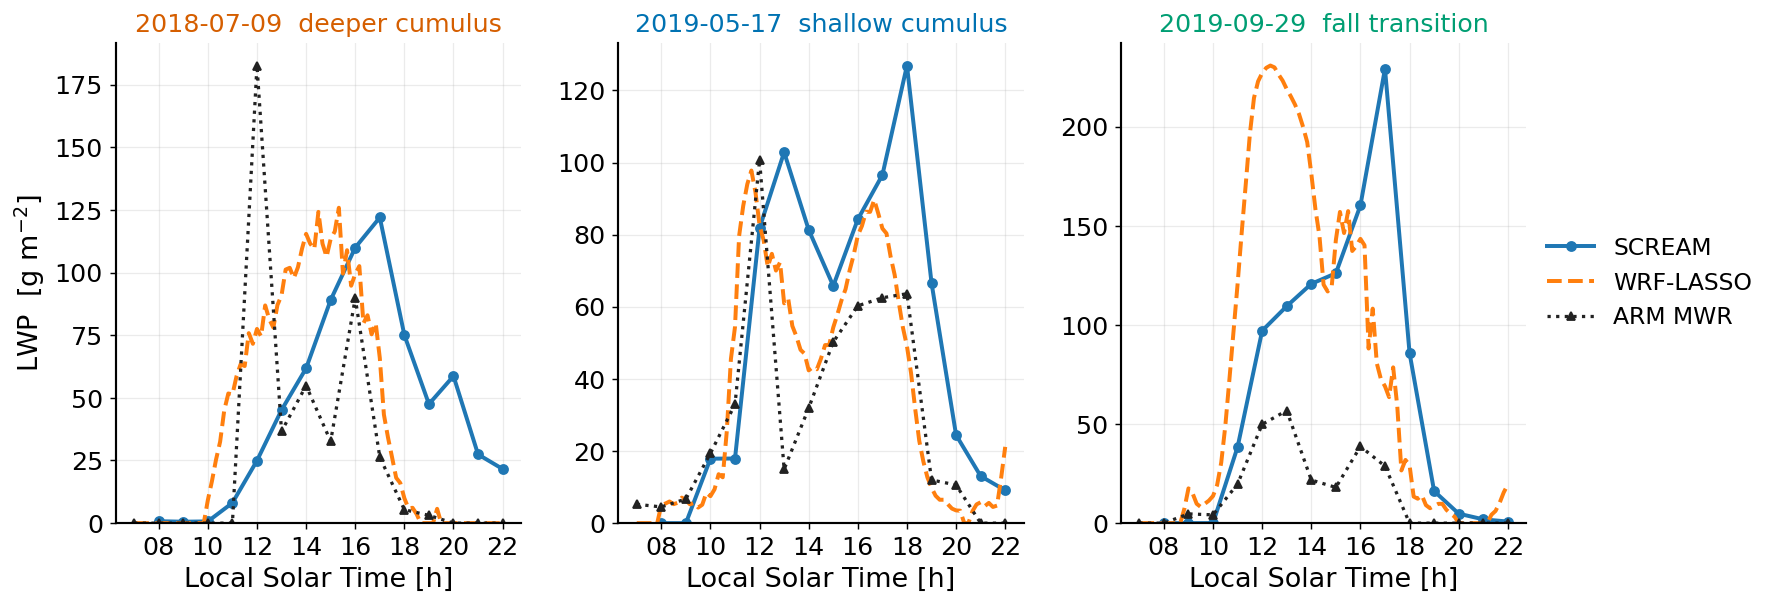

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), gridspec_kw=dict(wspace=0.24))

for ax, short in zip(axes, CASE_ORDER):
    b = BUNDLES[short]
    lwp_sc  = b['scream']['LiqWaterPath'].mean('ncol').values * 1000.0
    lwp_wrf = b['mod']['lwp'].values
    lwp_mwr = b['obsmod']['lwp'].isel(source_type=0).values

    ax.plot(b['t_sc'],  lwp_sc,  '-o', color=C_SCREAM, ms=5, label='SCREAM')
    ax.plot(b['t_mod'], lwp_wrf, '--', color=C_WRF,           label='WRF-LASSO')
    ax.plot(b['t_omd'], lwp_mwr, ':^', color=C_OBS, ms=4, lw=1.8, label='ARM MWR')

    ax.set_title(f"{b['date']}  {b['regime']}", color=CASE_COLOR[short])
    fmt_haxis(ax)
    ax.set_ylim(bottom=0)

axes[0].set_ylabel(r'LWP  [g m$^{-2}$]')
axes[2].legend(frameon=False, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

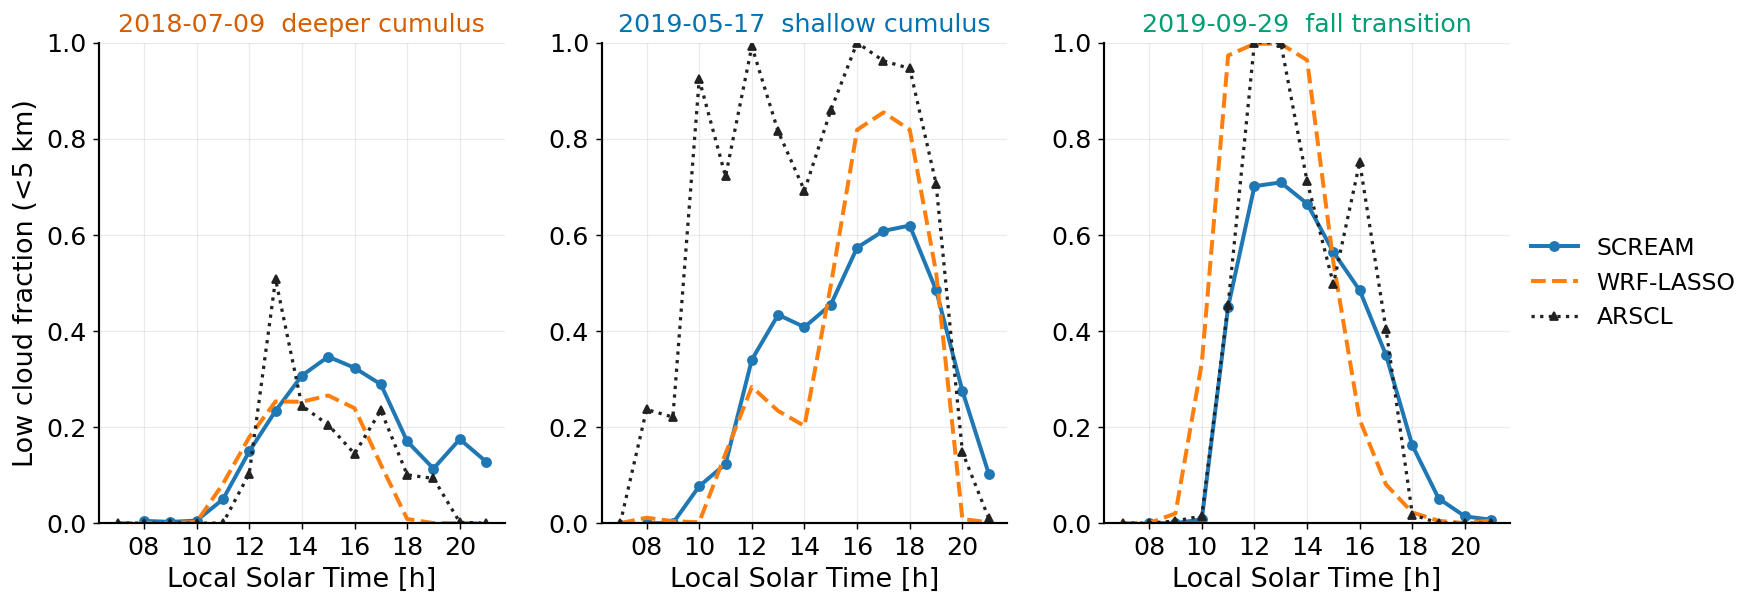

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), gridspec_kw=dict(wspace=0.24))

for ax, short in zip(axes, CASE_ORDER):
    b = BUNDLES[short]

    lcf_sc  = scream_low_cf(b['scream'])                                        # max(cldfrac_tot_for_analysis, z<5km).mean(ncol)
    lcf_wrf = b['obsmod']['low_cloud_fraction_arscl'].isel(source_type=1).values
    lcf_obs = b['obsmod']['low_cloud_fraction_arscl'].isel(source_type=0).values

    ax.plot(b['t_sc'][:-1],  lcf_sc[:-1],  '-o', color=C_SCREAM, ms=5, label='SCREAM')
    ax.plot(b['t_omd'][:-1], lcf_wrf[:-1], '--', color=C_WRF,          label='WRF-LASSO')
    ax.plot(b['t_omd'][:-1], lcf_obs[:-1], ':^', color=C_OBS, ms=4, lw=1.8, label='ARSCL')

    ax.set_title(f"{b['date']}  {b['regime']}", color=CASE_COLOR[short])
    fmt_haxis(ax)
    ax.set_ylim(0, 1)
    # ax.set_xlim(6, 21)

axes[0].set_ylabel('Low cloud fraction (<5 km)')
axes[2].legend(frameon=False, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()


## Fig 4 — Surface downwelling shortwave radiation

SCREAM outputs hourly averages; WRF wrfout files are also hourly. QCRAD observations are resampled to 10-minute means. Clouds suppress SW↓ relative to clear-sky — deviations from the smooth clear-sky curve diagnose cloud radiative effect.

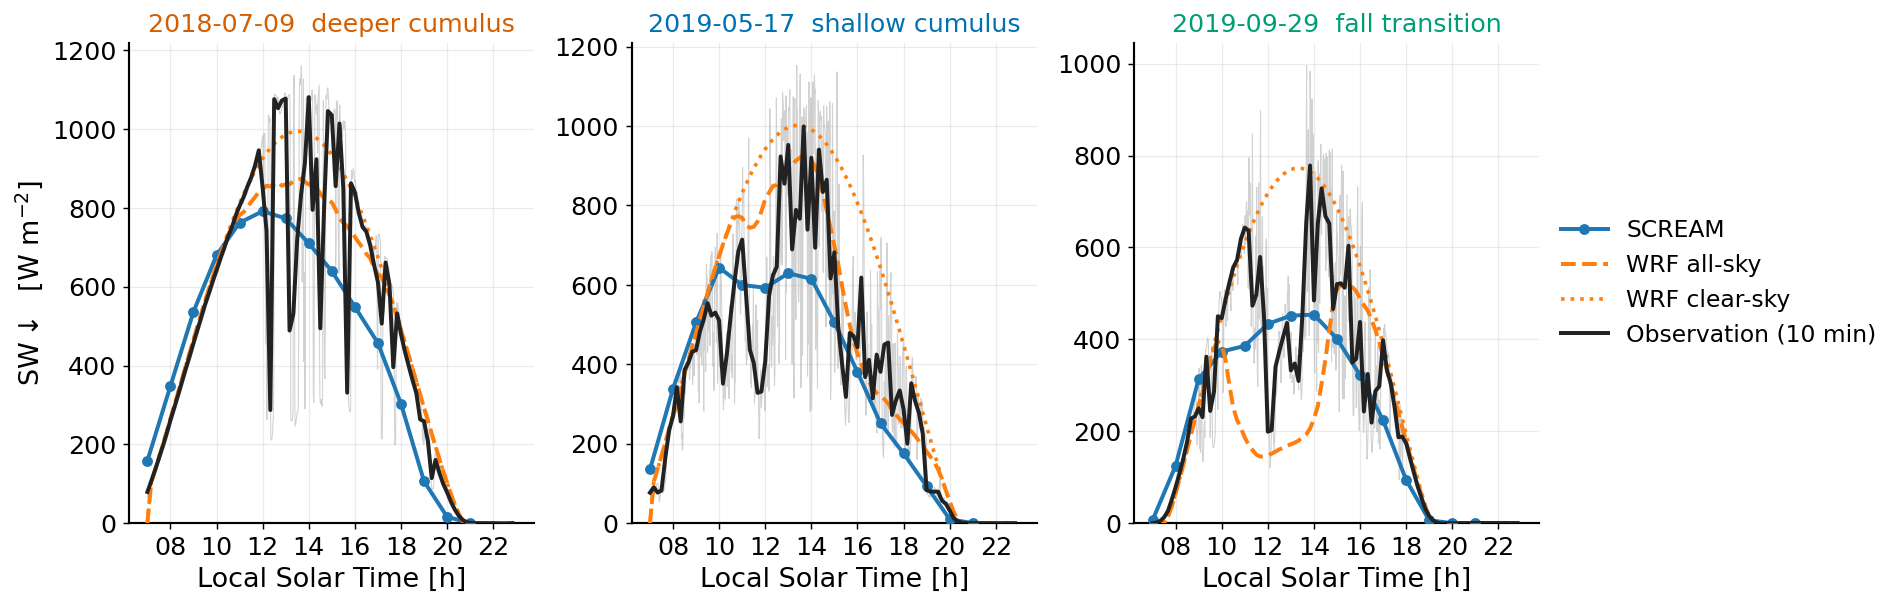

In [7]:
def load_sw_obs_raw(yyyymmdd):
  """Raw 1-minute QCRAD obs with no temporal averaging."""
  d = int(yyyymmdd)
  files = [str(SW_PATH / f'sgpqcrad1longE13.c2.{d}.000000.cdf'),
           str(SW_PATH / f'sgpqcrad1longE13.c2.{d+1}.000000.cdf')]
  sw = xr.open_mfdataset(files).BestEstimate_down_short_hemisp
  sw = sw.isel(time=slice(12 * 60, (24 + 4) * 60))
  return sw.assign_coords(time=sw.time + UTC_TO_LST)


def load_wrf_swdnbc(short):
  """WRF clear-sky SWDNB domain mean, times in LST."""
  pat   = CASES[short]['wrfout_glob']
  ds    = xr.open_mfdataset(sorted(glob(pat)), combine='nested', concat_dim='Time')
  times = pd.to_datetime(
      [bytes(t).decode().replace('_', 'T') for t in ds['Times'].values]
  ) + UTC_TO_LST
  return ds['SWDNBC'].assign_coords(Time=times).mean(['south_north', 'west_east'])


wrf_swdnbc = {s: load_wrf_swdnbc(s) for s in CASE_ORDER}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), gridspec_kw=dict(wspace=0.24))

for ax, short in zip(axes, CASE_ORDER):
  b = BUNDLES[short]

  # raw obs background: 1-minute, alpha=0.2
  sw_raw_obs = load_sw_obs_raw(CASES[short]['yyyymmdd'])
  ax.plot(sw_raw_obs.time.values, sw_raw_obs.values,
          color=C_OBS, alpha=0.2, lw=0.6, zorder=1)

  # domain means
  sw_sc_all = b['scream']['SW_flux_dn_at_model_bot']
  t_sc_sw = b['t_sc'] - pd.Timedelta(hours=1)   # shift to start of averaging window

  ax.plot(t_sc_sw, sw_sc_all.mean('ncol').values,
          '-o', color=C_SCREAM, ms=5, lw=2.2, zorder=4, label='SCREAM')
  ax.plot(wrf_swdnb[short].coords['Time'].values, wrf_swdnb[short].values,
          '--', color=C_WRF, lw=2.2, zorder=4, label='WRF all-sky')
  ax.plot(wrf_swdnbc[short].coords['Time'].values, wrf_swdnbc[short].values,
          ':', color=C_WRF, lw=2.0, zorder=3, label='WRF clear-sky')
  ax.plot(sw_obs[short].time.values, sw_obs[short].values,
          color=C_OBS, lw=2.2, zorder=4, label='Observation (10 min)')

  ax.set_title(f"{b['date']}  {b['regime']}", color=CASE_COLOR[short])
  fmt_haxis(ax)
  ax.set_ylim(bottom=0)

axes[0].set_ylabel(r'SW$\downarrow$  [W m$^{-2}$]')
axes[2].legend(frameon=False, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.show()

## Fig 5 — Potential temperature profiles

Three time snapshots (07, 12, 17 LST) for each case. Solid blue = SCREAM domain mean, solid orange = WRF-LASSO. The initial sounding (ARM rawinsonde) is shown only at 07 LST (dashed black). Horizontal lines mark the observed LCL (dashed green) and cloud-base height (dotted purple) at each snapshot time.

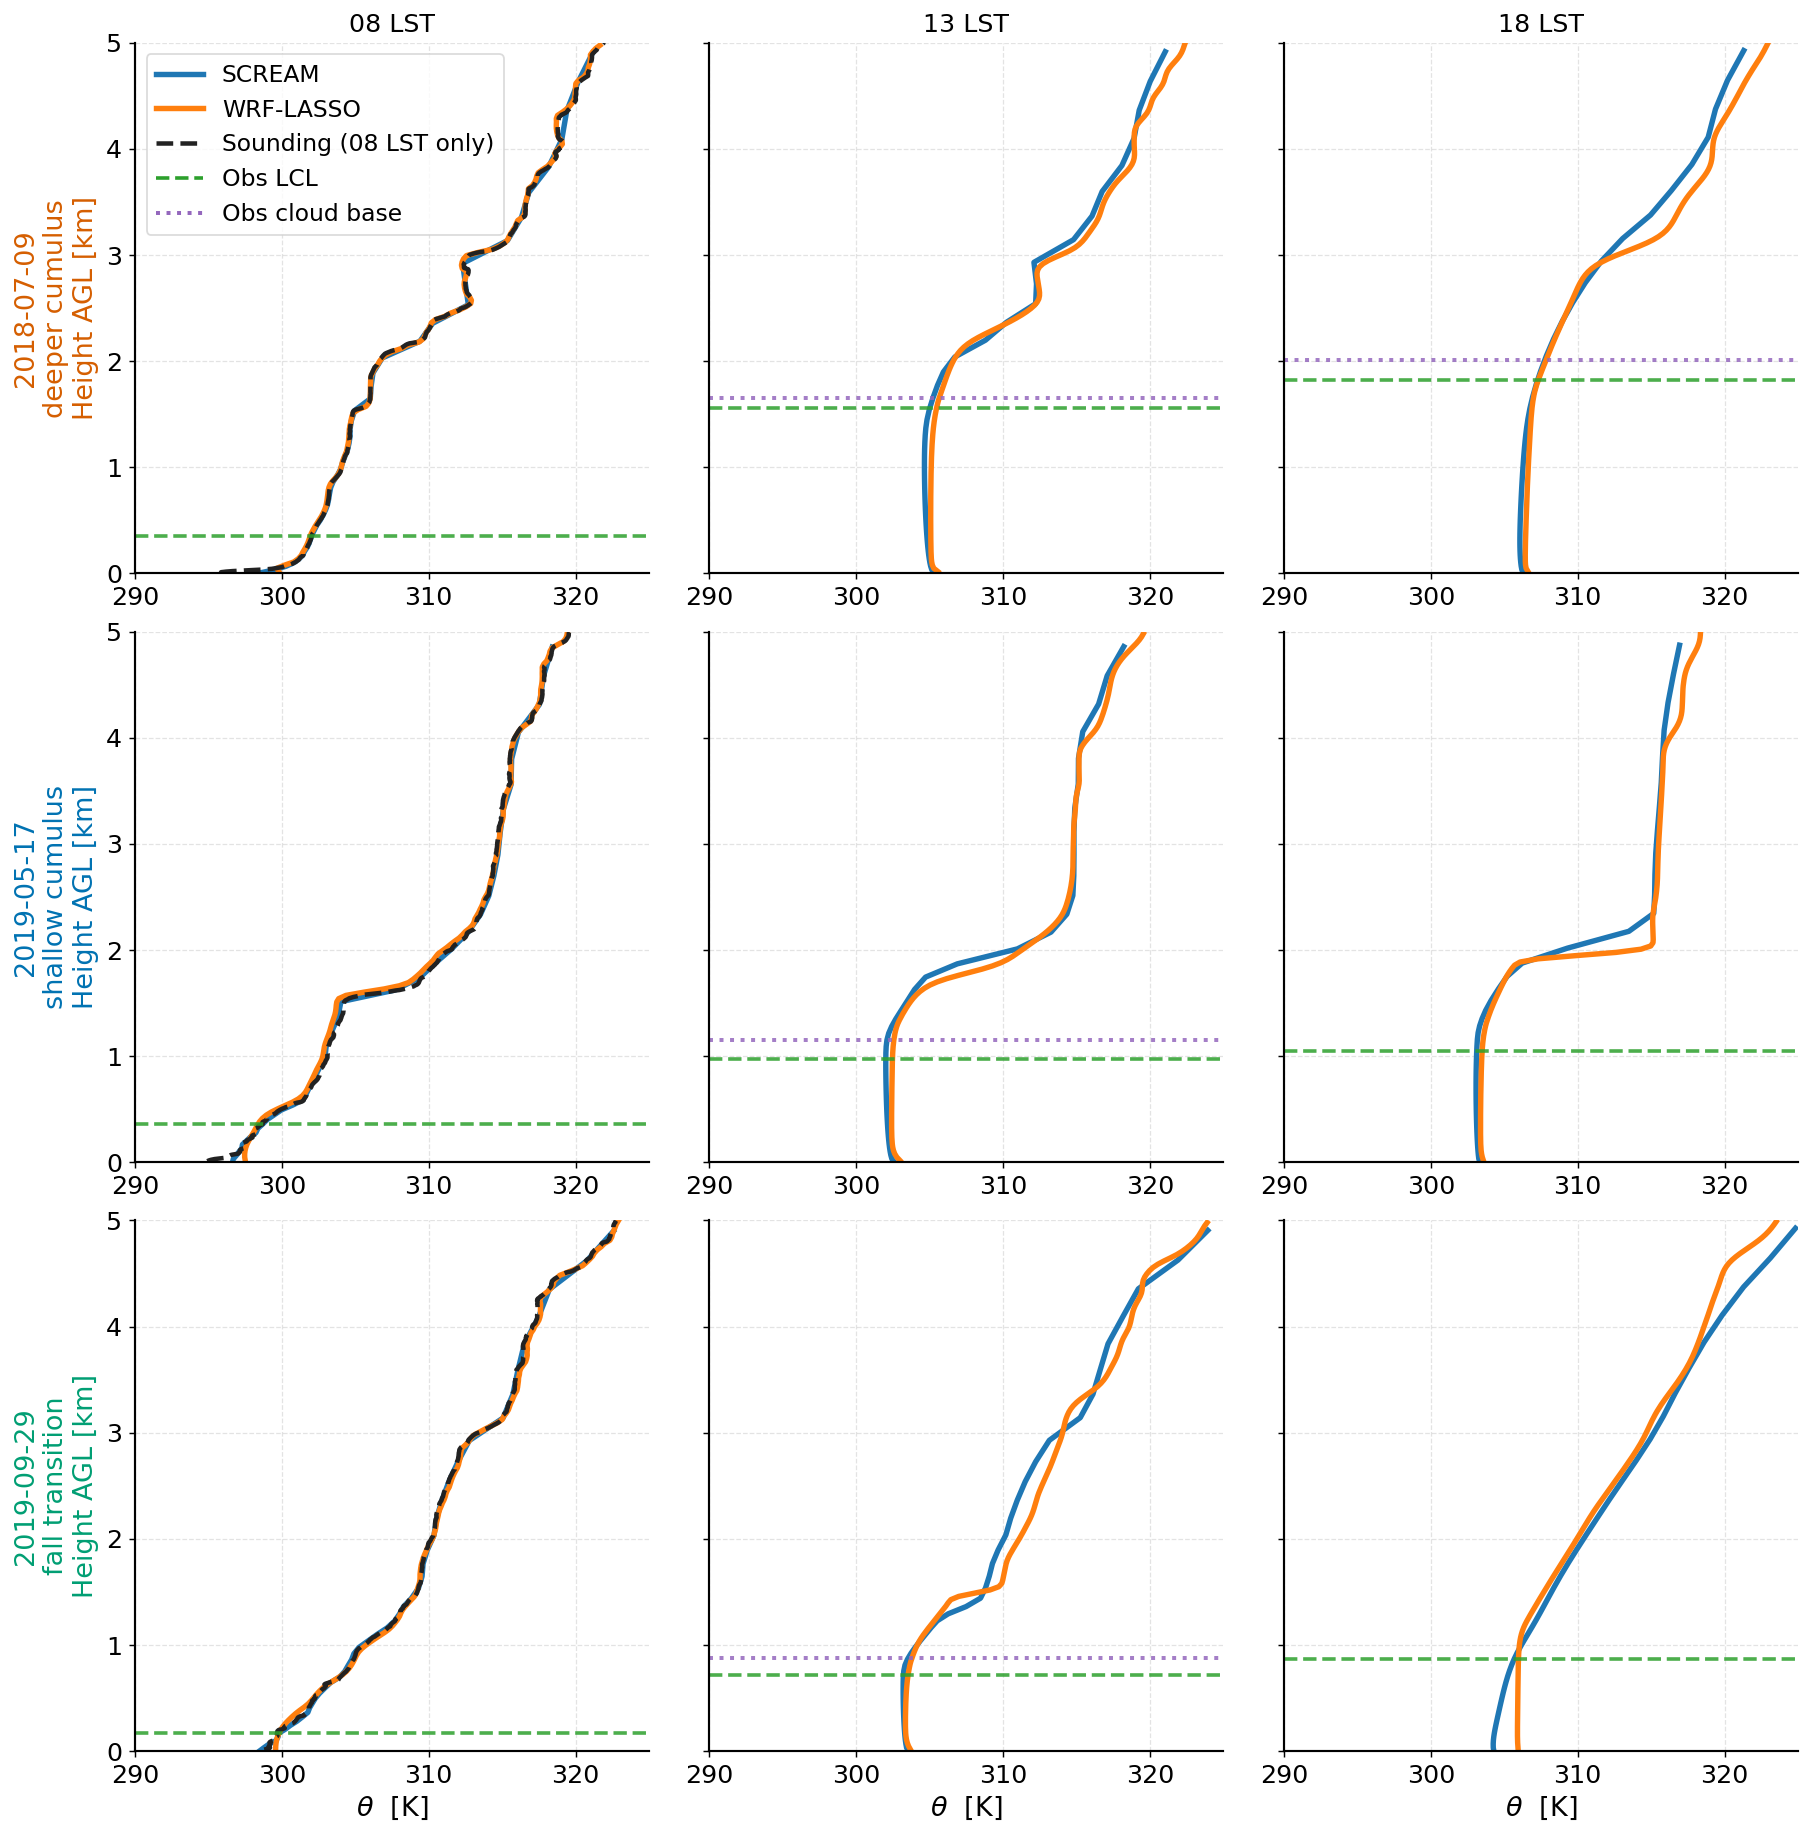

In [8]:
SNAP_HOURS  = [8, 13, 18]       # LST (UTC-5); avoids WRF's NaN-height first time step at 07:00
SNAP_LABELS = ['08 LST', '13 LST', '18 LST']
THETA_MIN, THETA_MAX, Z_MAX = 290, 325, 5.0

fig, axes = plt.subplots(3, 3, figsize=(14, 14), sharey=True, constrained_layout=True)

for row, short in enumerate(CASE_ORDER):
    b    = BUNDLES[short]
    sc   = b['scream']
    wrf  = b['mod']
    diag = b['obsmod']

    z_sc_t   = b['z_sc_km_t']                             # DataArray (time, lev) km AGL
    theta_sc = sc['PotentialTemperature'].mean('ncol')     # (time, lev)

    theta_snd, z_snd = load_sounding(short)
    mask_snd = z_snd < Z_MAX

    for col, hr in enumerate(SNAP_HOURS):
        ax = axes[row, col]
        # Target in LST -- no UTC_TO_LST here; b['t_*'] are already in LST
        ts = pd.Timestamp(f"{b['date']} {hr:02d}:00")

        i_sc  = nearest_t(b['t_sc'],  ts)
        i_mod = nearest_t(b['t_mod'], ts)
        i_omd = nearest_t(b['t_omd'], ts)

        # SCREAM profile
        z_sc_prof     = z_sc_t.isel(time=i_sc).values
        theta_sc_prof = theta_sc.isel(time=i_sc).values
        mask_sc = (z_sc_prof >= 0) & (z_sc_prof < Z_MAX)

        # WRF profile -- use height_km at the selected time step, mask NaN
        z_wrf_prof     = wrf['height_km'].isel(time=i_mod).values
        theta_wrf_prof = wrf['potential_temp'].isel(time=i_mod).values
        mask_wrf = np.isfinite(z_wrf_prof) & (z_wrf_prof >= 0) & (z_wrf_prof < Z_MAX)

        ax.plot(theta_sc_prof[mask_sc], z_sc_prof[mask_sc],
                color=C_SCREAM, lw=3.0, label='SCREAM')
        ax.plot(theta_wrf_prof[mask_wrf], z_wrf_prof[mask_wrf],
                color=C_WRF, lw=3.0, label='WRF-LASSO')

        if col == 0:
            ax.plot(theta_snd[mask_snd], z_snd[mask_snd],
                    '--', color=C_OBS, lw=2.5, label='Sounding')

        lcl = float(diag['lcl'].isel(source_type=0).isel(time=i_omd).values) / 1000.0
        cb  = float(diag['cloud_base_height'].isel(source_type=0).isel(time=i_omd).values) / 1000.0
        if 0.05 < lcl < Z_MAX:
            ax.axhline(lcl, ls='--', lw=2.0, color=C_LCL, alpha=0.85)
        if 0.05 < cb  < Z_MAX:
            ax.axhline(cb,  ls=':',  lw=2.2, color=C_CB,  alpha=0.85)

        ax.set_xlim(THETA_MIN, THETA_MAX)
        ax.set_ylim(0, Z_MAX)
        ax.grid(which='major', ls='--', lw=0.7, alpha=0.35)

        if row == 0:
            ax.set_title(SNAP_LABELS[col])
        if col == 0:
            ax.set_ylabel(f"{b['date']}\n{b['regime']}\nHeight AGL [km]",
                          color=CASE_COLOR[short])
        if row == 2:
            ax.set_xlabel(r'$\theta$  [K]')

legend_handles = [
    Line2D([0],[0], color=C_SCREAM, lw=3.0,          label='SCREAM'),
    Line2D([0],[0], color=C_WRF,    lw=3.0,          label='WRF-LASSO'),
    Line2D([0],[0], color=C_OBS,    lw=2.5, ls='--', label='Sounding (08 LST only)'),
    Line2D([0],[0], color=C_LCL,    lw=2.0, ls='--', label='Obs LCL'),
    Line2D([0],[0], color=C_CB,     lw=2.2, ls=':',  label='Obs cloud base'),
]
axes[0, 0].legend(handles=legend_handles, frameon=True, facecolor='white',
                  edgecolor='lightgray', fontsize=13)
plt.show()

## Fig 6 — WRF-LASSO thermodynamic curtains

Time–height evolution of potential temperature (top row) and water-vapour mixing ratio (bottom row) from WRF-LASSO. The diurnal boundary-layer growth is clearest in θ; the moistening aloft during convective periods appears in qᵥ.

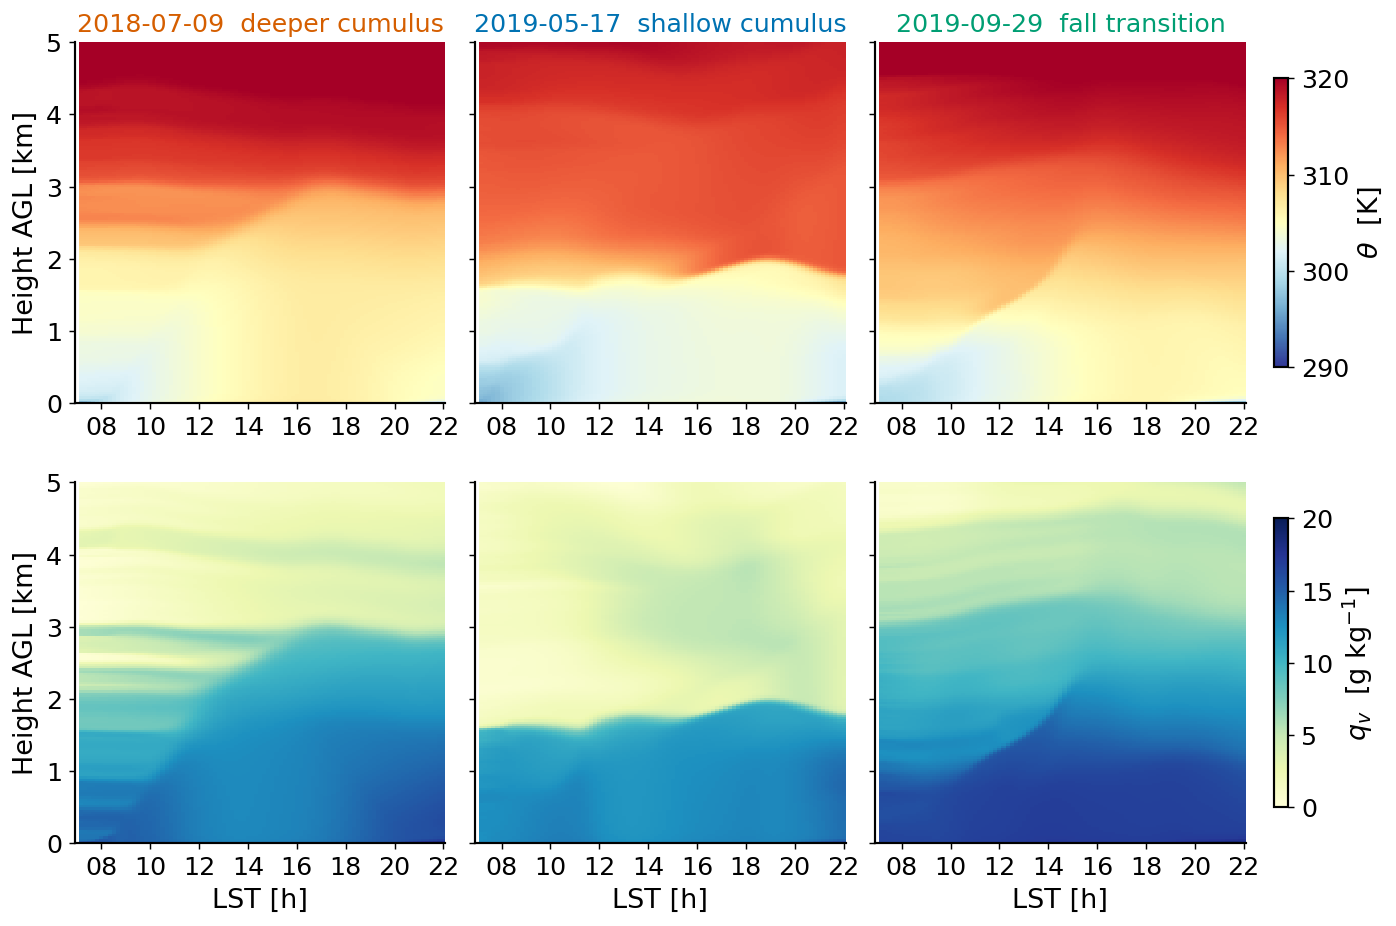

In [9]:
vars_cfg = [
    {'var': 'potential_temp',           'vmin': 290, 'vmax': 320, 'cmap': 'RdYlBu_r',
     'label': r'$\theta$  [K]'},
    {'var': 'water_vapor_mixing_ratio', 'vmin': 0,   'vmax': 20,  'cmap': 'YlGnBu',
     'label': r'$q_v$  [g kg$^{-1}$]'},
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=False, sharey=True,
                         gridspec_kw=dict(hspace=0.22, wspace=0.08))

for row, cfg in enumerate(vars_cfg):
    for col, short in enumerate(CASE_ORDER):
        b   = BUNDLES[short]
        mod = b['mod']
        ax  = axes[row, col]

        z   = mod['height_km'].mean('time').values   # km from the same mod file
        t   = b['t_mod']
        arr = mod[cfg['var']].values.T               # (height, time)

        # qv may be in kg/kg depending on VAP version; convert to g/kg
        if cfg['var'] == 'water_vapor_mixing_ratio' and arr.max() < 1.0:
            arr = arr * 1000.0

        good = pd.notnull(t)
        pc = ax.pcolormesh(t[good], z, arr[:, good],
                           cmap=cfg['cmap'], vmin=cfg['vmin'], vmax=cfg['vmax'],
                           shading='auto')
        ax.set_ylim(0, 5)
        ax.grid(False)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H'))

        if row == 0:
            ax.set_title(f"{b['date']}  {b['regime']}", color=CASE_COLOR[short])
        if col == 0:
            ax.set_ylabel('Height AGL [km]')
        if row == 1:
            ax.set_xlabel('LST [h]')

    fig.colorbar(pc, ax=axes[row, :], shrink=0.8, pad=0.02, label=cfg['label'])

plt.show()


## Fig 7 & 8 — Cloud-water budget diagnostics

**Fig 7** normalises all cloud-occurrence metrics to the LASSO reference. A bar at 1 means model = LASSO. Blue bars use SCREAM's internal cloud label (`cldfrac_tot`); orange bars count SCREAM cells that actually carry real condensate (`qc + qr > 1×10⁻⁷ kg/kg`).

**Fig 8** tests the Zhang et al. (2024 GRL) mechanism: afternoon (12–18 LST) SCREAM columns, each plotted as boundary-layer height vs column LWP. A positive slope means taller BL → more condensate.

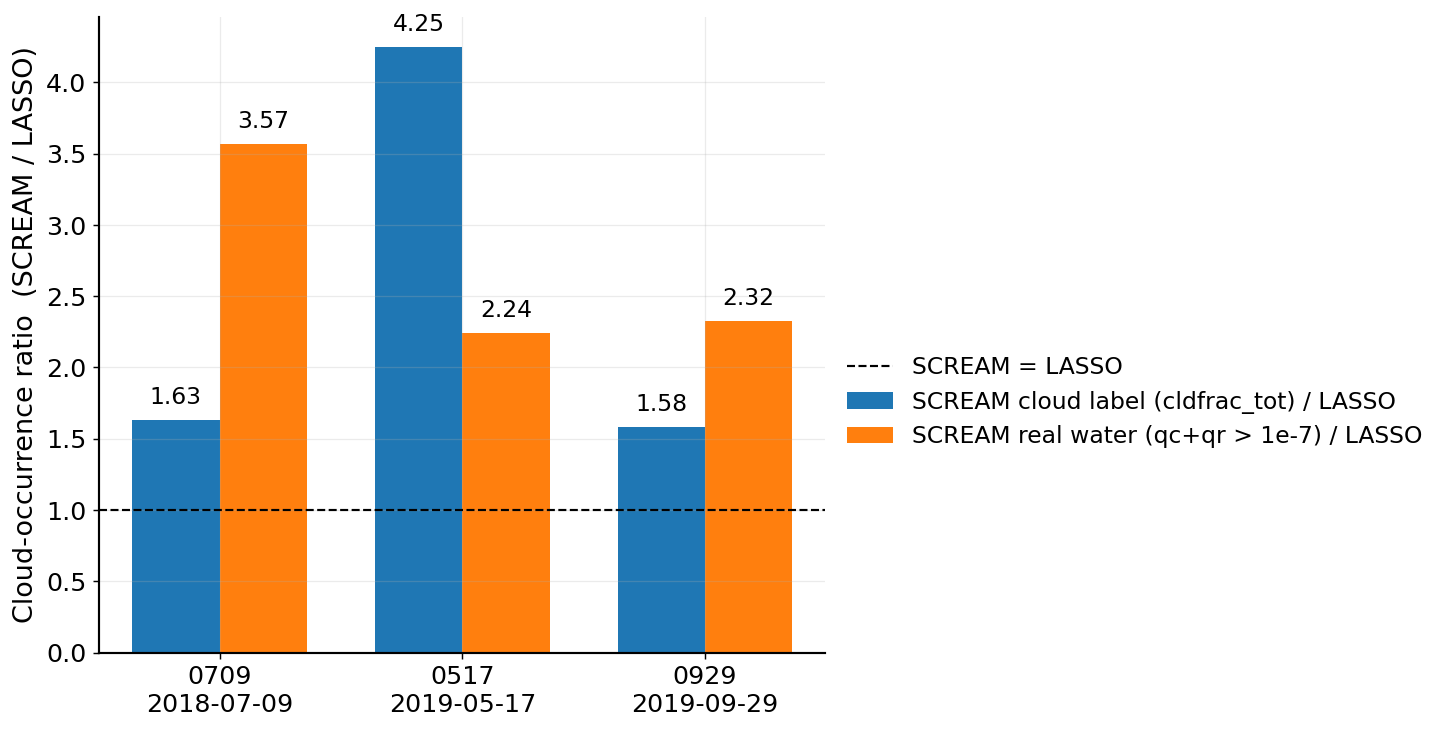

In [10]:
WATER_THRESH = 1e-7
CF_THRESH    = 0.01

rows = []
for short in CASE_ORDER:
    b  = BUNDLES[short]
    sc = b['scream']
    oz = b['obsmodz']

    cf_label = sc['cldfrac_tot'].mean('ncol').values
    cf_water = ((sc['qc'] + sc['qr']) > WATER_THRESH).mean('ncol').values
    cf_lasso = oz['cloud_fraction'].values

    rows.append(dict(
        case=short,
        occ_label = float((cf_label >= CF_THRESH).mean()),
        occ_water = float((cf_water >= CF_THRESH).mean()),
        occ_lasso = float((cf_lasso >= CF_THRESH).mean()),
    ))

m = pd.DataFrame(rows).set_index('case').loc[CASE_ORDER].reset_index()
m['ratio_label'] = m['occ_label'] / m['occ_lasso']
m['ratio_water'] = m['occ_water'] / m['occ_lasso']

fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
xpos = np.arange(3)
w    = 0.36
b1 = ax.bar(xpos - w/2, m['ratio_label'], w, color=C_SCREAM, label='SCREAM cloud label (cldfrac_tot) / LASSO')
b2 = ax.bar(xpos + w/2, m['ratio_water'], w, color=C_WRF,    label='SCREAM real water (qc+qr > 1e-7) / LASSO')
ax.axhline(1.0, color='k', ls='--', lw=1.2, label='SCREAM = LASSO')

labels = [f"{s}\n{CASES[s]['date']}" for s in CASE_ORDER]
ax.set_xticks(xpos)
ax.set_xticklabels(labels)
ax.set_ylabel('Cloud-occurrence ratio  (SCREAM / LASSO)')
ax.legend(frameon=False, bbox_to_anchor=(1.0, 0.5))

for bar, val in list(zip(b1, m['ratio_label'])) + list(zip(b2, m['ratio_water'])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08,
            f'{val:.2f}', ha='center', va='bottom', fontsize=13)

plt.show()

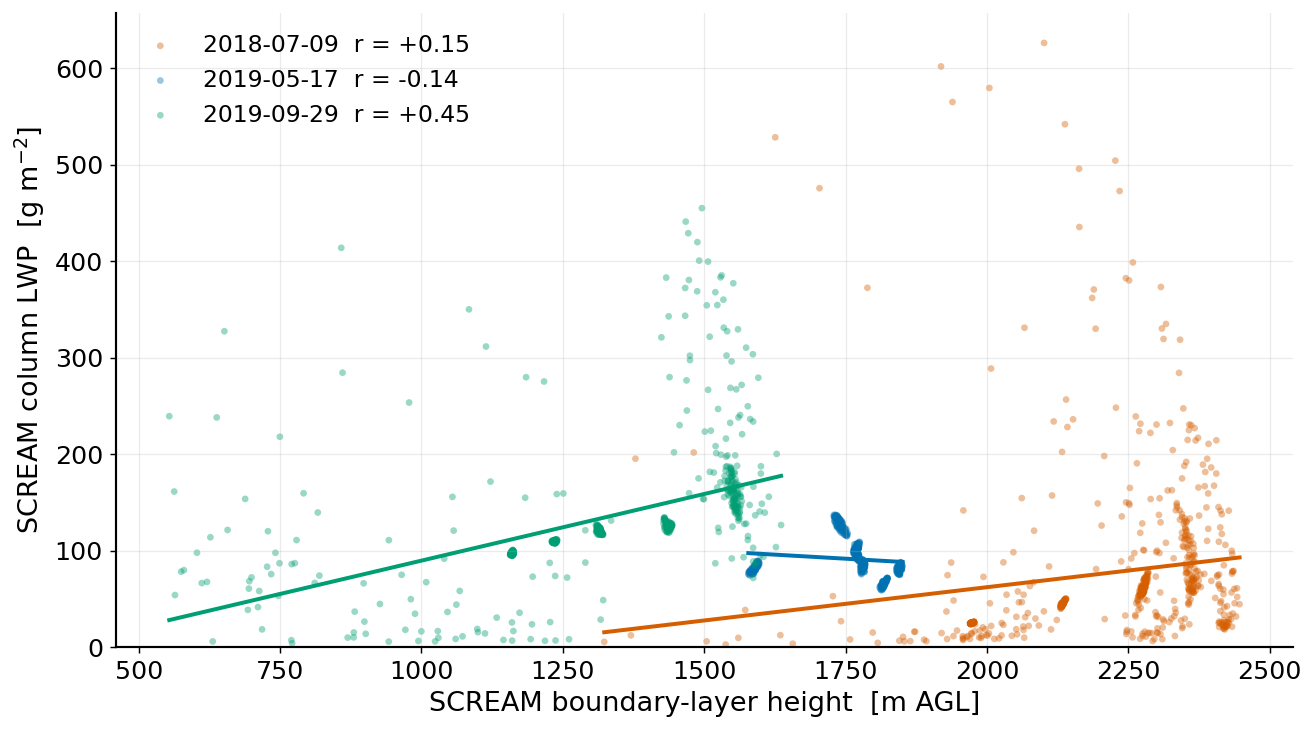

In [11]:
from scipy.stats import pearsonr

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)

for short in CASE_ORDER:
    b     = BUNDLES[short]
    sc    = b['scream']
    t_lst = b['t_sc']
    hour  = t_lst.hour + t_lst.minute / 60.0
    mask  = (hour >= 12) & (hour <= 18)

    pblh = sc['pbl_height'].isel(time=mask).values.flatten()
    lwp  = sc['LiqWaterPath'].isel(time=mask).values.flatten() * 1000.0
    good = np.isfinite(pblh) & np.isfinite(lwp)
    pblh, lwp = pblh[good], lwp[good]

    r, _ = pearsonr(pblh, lwp)
    col   = CASE_COLOR[short]
    ax.scatter(pblh, lwp, s=14, alpha=0.4, color=col, edgecolors='none',
               label=f"{CASES[short]['date']}  r = {r:+.2f}")
    if len(pblh) > 2:
        slope, intercept = np.polyfit(pblh, lwp, 1)
        xl = np.array([pblh.min(), pblh.max()])
        ax.plot(xl, slope * xl + intercept, '-', color=col, lw=2.2)

ax.set_xlabel('SCREAM boundary-layer height  [m AGL]')
ax.set_ylabel(r'SCREAM column LWP  [g m$^{-2}$]')
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
plt.show()

## Fig 9 — Model vs. observation scatter: boundary-layer state and low cloud fraction

Each point is one matched time step across all three cases (CASE_COLOR not used here — cases are pooled). 
SCREAM (blue circles) vs. WRF-LASSO (orange triangles) on the same axes; 1:1 line dashed black.
Unit conversions applied: SCREAM RH × 100 (fraction → %).

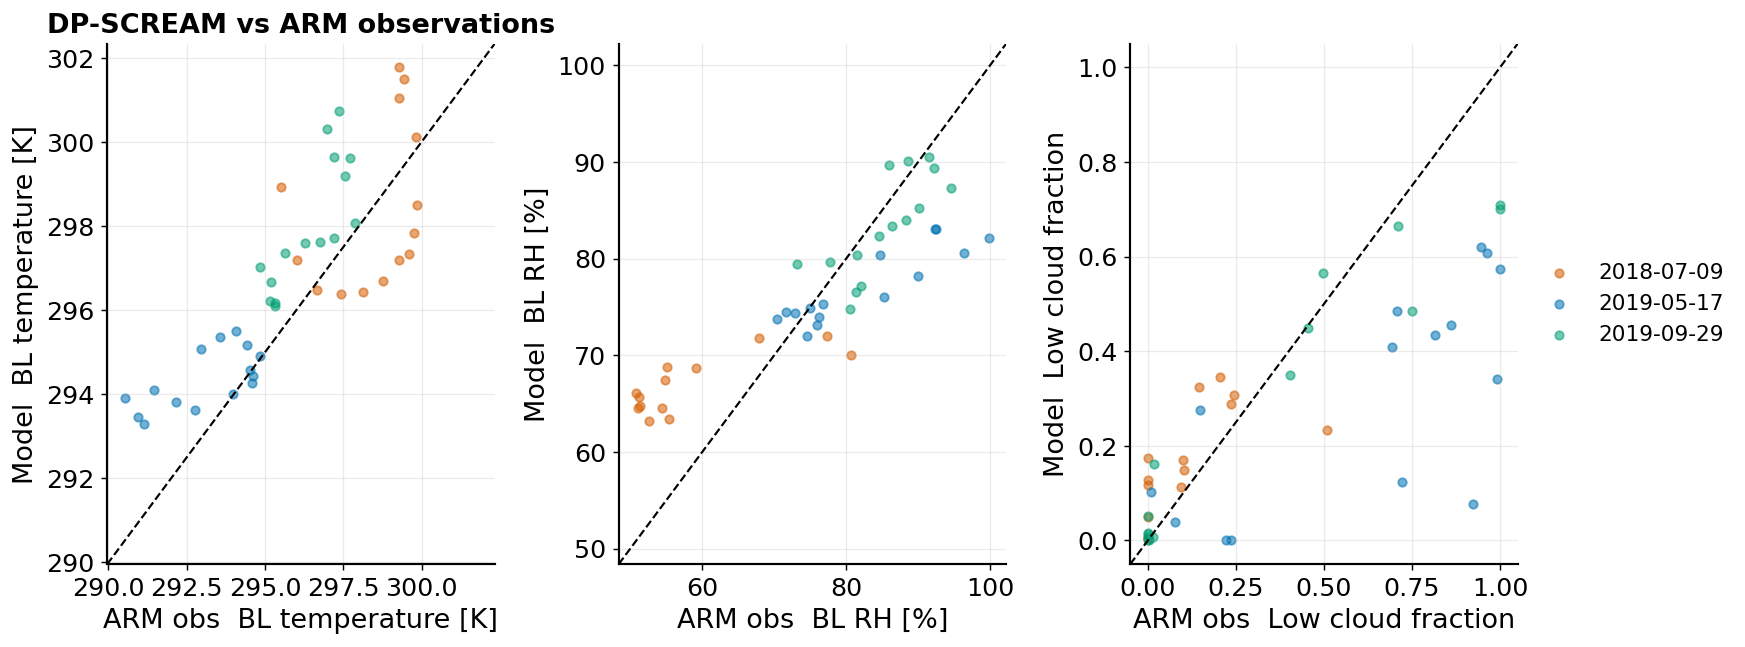

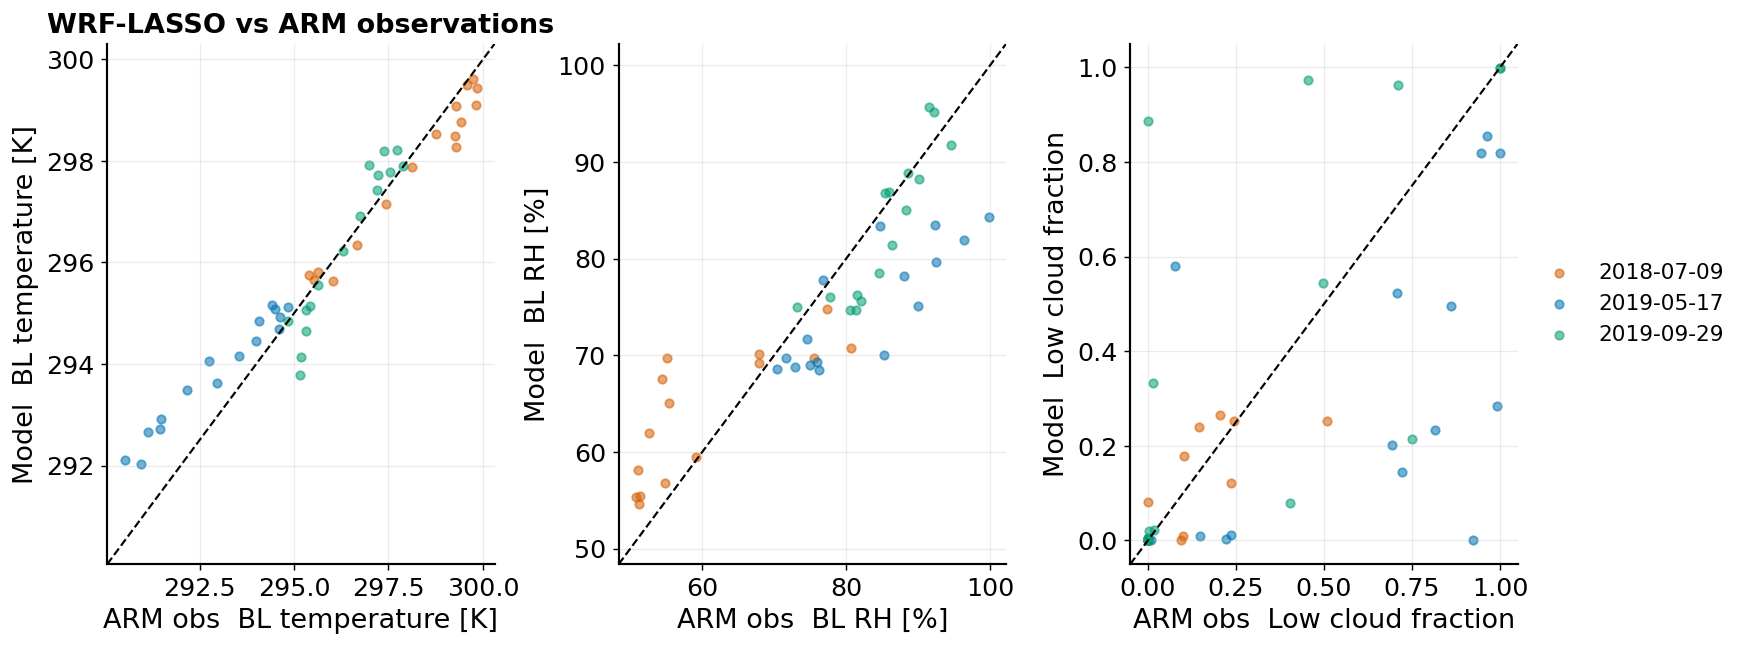

In [12]:
def scream_bl_mean(ds, varname):
    z  = ds['z_mid']
    da = ds[varname]
    if 'pbl_height' in ds:
        mask = z <= ds['pbl_height']
    else:
        mask = z <= 1000.0
    return da.where(mask).mean(dim=['ncol', 'lev'], skipna=True).values


def align_pairs(t_obs, y_obs, t_mod, y_mod, tol='45min'):
    obs_s = pd.Series(np.asarray(y_obs, float), index=pd.DatetimeIndex(t_obs)).sort_index()
    mod_s = pd.Series(np.asarray(y_mod, float), index=pd.DatetimeIndex(t_mod)).sort_index()
    obs_m = obs_s.reindex(mod_s.index, method='nearest', tolerance=pd.Timedelta(tol))
    good  = obs_m.notna() & mod_s.notna()
    return obs_m[good].values, mod_s[good].values


SCATTER_VARS = [
    ('temperature_boundary_layer', 'BL temperature [K]'),
    ('rh_boundary_layer',          'BL RH [%]'),
    ('low_cloud_fraction_arscl',   'Low cloud fraction'),
]

SC_UNIT = {
    'temperature_boundary_layer': (1.0,   0.0),
    'rh_boundary_layer':          (100.0, 0.0),
    'low_cloud_fraction_arscl':   (1.0,   0.0),
}

# collect per-case paired data
case_pairs = {}
for short in CASE_ORDER:
    b  = BUNDLES[short]
    sc = b['scream']

    sc_vals = {
        'temperature_boundary_layer': scream_bl_mean(sc, 'T_mid'),
        'rh_boundary_layer':          scream_bl_mean(sc, 'RelativeHumidity'),
        'low_cloud_fraction_arscl':   scream_low_cf(sc),
    }

    case_pairs[short] = {}
    for varname, _ in SCATTER_VARS:
        y_obs = b['obsmod'][varname].isel(source_type=0).values
        y_wrf = b['obsmod'][varname].isel(source_type=1).values
        t_omd = b['t_omd']

        good_wrf = np.isfinite(y_obs) & np.isfinite(y_wrf)
        scale, offset = SC_UNIT[varname]
        sc_conv = sc_vals[varname] * scale + offset
        sc_obs, sc_mod = align_pairs(t_omd, y_obs, b['t_sc'], sc_conv)

        case_pairs[short][varname] = {
            'wrf': (y_obs[good_wrf], y_wrf[good_wrf]),
            'sc':  (sc_obs, sc_mod),
        }


def _scatter_panel(axes_row, model_key, title):
    for ax, (varname, xlabel) in zip(axes_row, SCATTER_VARS):
        for short in CASE_ORDER:
            obs, mod = case_pairs[short][varname][model_key]
            ax.scatter(obs, mod, color=CASE_COLOR[short], alpha=0.55, s=22,
                       label=CASES[short]['date'])

        all_v = np.concatenate([np.concatenate(case_pairs[s][varname][model_key])
                                 for s in CASE_ORDER])
        lo, hi = np.nanmin(all_v), np.nanmax(all_v)
        pad = 0.05 * (hi - lo)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1.2)
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xlabel(f'ARM obs  {xlabel}')
        ax.set_ylabel(f'Model  {xlabel}')

    axes_row[0].set_title(title, fontsize=15, weight='semibold')
    axes_row[2].legend(frameon=False, loc='center left',
                       bbox_to_anchor=(1.0, 0.5), fontsize=12)


fig_sc, ax_sc = plt.subplots(1, 3, figsize=(14, 5.2), gridspec_kw=dict(wspace=0.32))
_scatter_panel(ax_sc, 'sc', 'DP-SCREAM vs ARM observations')
plt.show()

fig_wrf, ax_wrf = plt.subplots(1, 3, figsize=(14, 5.2), gridspec_kw=dict(wspace=0.32))
_scatter_panel(ax_wrf, 'wrf', 'WRF-LASSO vs ARM observations')
plt.show()


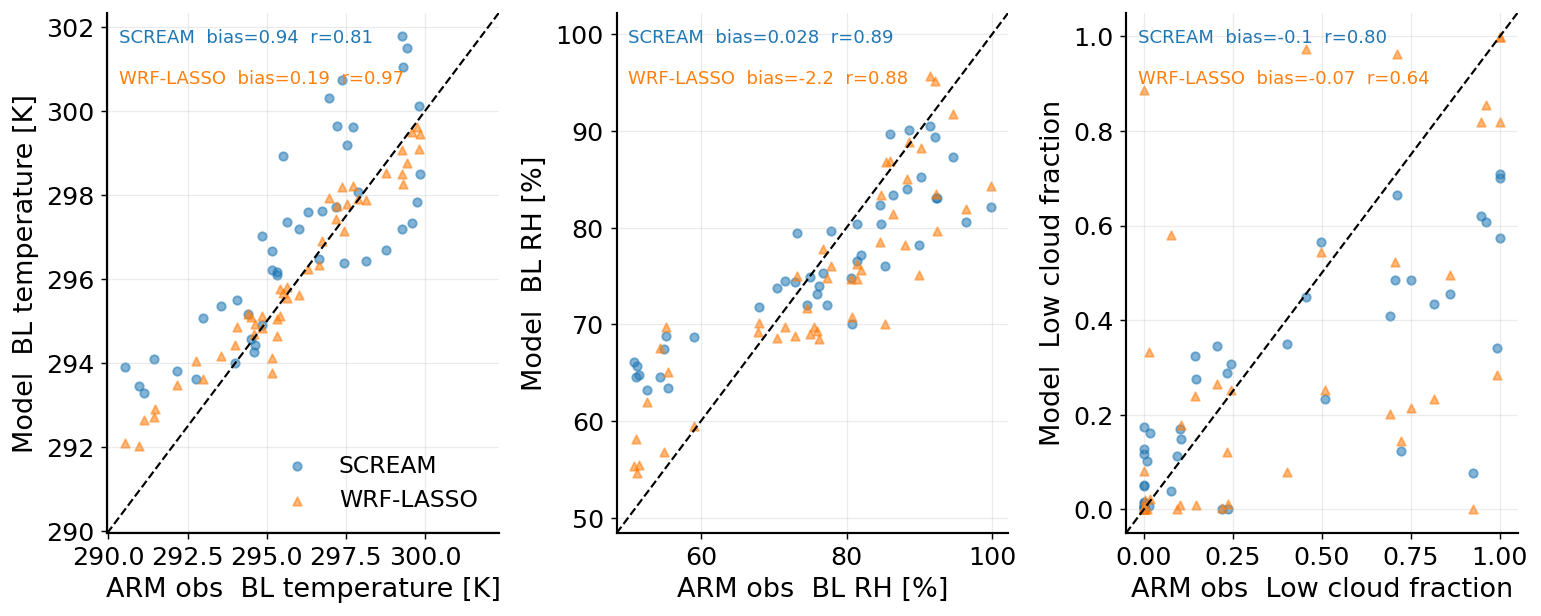

In [13]:
# pooled across all cases, both models on one figure
def scatter_metrics(obs, mod, ax, color, prefix=''):
    good = np.isfinite(obs) & np.isfinite(mod)
    if good.sum() < 2:
        return
    bias = np.mean(mod[good] - obs[good])
    r    = np.corrcoef(obs[good], mod[good])[0, 1]
    label = f'{prefix}  bias={bias:.2g}  r={r:.2f}'
    ax.text(0.03, 0.97 if prefix.startswith('S') else 0.89,
            label, transform=ax.transAxes, va='top', fontsize=10, color=color)


fig, axes = plt.subplots(1, 3, figsize=(14, 5.2), gridspec_kw=dict(wspace=0.30))

for ax, (varname, xlabel) in zip(axes, SCATTER_VARS):
    for key, col, marker, label in [('sc',  C_SCREAM, 'o', 'SCREAM'),
                                     ('wrf', C_WRF,    '^', 'WRF-LASSO')]:
        obs = np.concatenate([case_pairs[s][varname][key][0] for s in CASE_ORDER])
        mod = np.concatenate([case_pairs[s][varname][key][1] for s in CASE_ORDER])
        ax.scatter(obs, mod, color=col, marker=marker, alpha=0.55, s=22, label=label)
        scatter_metrics(obs, mod, ax, col, prefix=label)

    all_v = np.concatenate([np.concatenate(case_pairs[s][varname][k])
                             for s in CASE_ORDER for k in ('sc', 'wrf')])
    lo, hi = np.nanmin(all_v), np.nanmax(all_v)
    pad = 0.05 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1.2)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(f'ARM obs  {xlabel}')
    ax.set_ylabel(f'Model  {xlabel}')

axes[0].legend(frameon=False, loc='lower right')
plt.show()
